# 📱 Google Play Store Apps — Exploratory Data Analysis

## 🎯 Project Objective
This project explores the Google Play Store apps dataset to understand app ratings, installs, pricing, categories, and update trends. The workflow covers data cleaning, missing value handling, dtype optimization, and univariate/bivariate visual analysis using `pandas`, `numpy`, `matplotlib`, and `seaborn`.

## 📋 Dataset Overview
The dataset contains app-level records scraped from the Google Play Store, commonly used as a beginner-to-intermediate benchmark dataset for EDA practice. It has **10,841 rows and 13 columns**.

**Columns:**

| Column           | Description                                                        |
|------------------|---------------------------------------------------------------------|
| `App`            | Name of the application                                            |
| `Category`       | Category the app belongs to (e.g. GAME, FAMILY, TOOLS)             |
| `Rating`         | Average user rating of the app                                     |
| `Reviews`        | Number of user reviews                                             |
| `Size`           | Size of the app (in MB/KB)                                         |
| `Installs`       | Number of installs                                                 |
| `Type`           | Free or Paid                                                        |
| `Price`          | Price of the app (in $)                                            |
| `Content Rating` | Target audience (Everyone, Teen, Mature, etc.)                      |
| `Genres`         | Genre(s) the app is listed under                                   |
| `Last Updated`   | Date the app was last updated                                      |
| `Current Ver`    | Current version of the app                                         |
| `Android Ver`    | Minimum Android version required                                   |

## 🛠️ Tools Used
- Python
- pandas
- NumPy
- matplotlib
- seaborn
- Jupyter Notebook

## 🧹 Data Cleaning
- Removed **483 duplicate rows** from the dataset.
- Dropped 1 corrupted row (values were misaligned across columns).
- Cleaned `Installs` by removing `,` and `+` symbols and converting to numeric.
- Cleaned `Price` by removing `$` and converting to numeric.
- Converted `Reviews` to numeric and filled missing `Rating` values with the median.
- Cleaned `Size` by converting `M`/`K` suffixes into a consistent numeric (MB) scale, filling missing values using category-wise median.
- Filled missing `Type` values with the mode.
- Converted `Last Updated` to `datetime` and extracted `Year Updated` and `Month Updated` columns.
- Filled missing `Current Ver` and `Android Ver` values with their mode.
- Optimized dtypes: converted `Category`, `Type`, and `Content Rating` to `category` for memory efficiency.
- Final cleaned dataset: **10,357 rows and 15 columns**.

---
### 📦 Importing Libraries
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
### 📥 Loading and Understanding the Dataset
---

In [2]:
df = pd.read_csv('googleplaystore.csv')
df.shape

(10841, 13)

In [3]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [6]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(483)

---
### 🧹Data Cleaning
---

In [8]:
# Remove duplicate rows from the DataFrame
df = df.drop_duplicates().reset_index(drop=True)

*Cleaning Install column*

In [9]:
# This row is corrupted so drop it (all Values are misplaced)
df[df['Installs'] == 'Free'] 

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9990,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [10]:
df = df.drop(9990)

In [11]:
#removing ',' and '+'
df["Installs"] = df["Installs"].str.replace(",", "").str.replace("+", "", regex=False)
#converting this column into numeric
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

*Cleaning Price column*

In [12]:
#removing '$'
df["Price"] = df["Price"].str.replace('$','',regex=False)
#converting this column into numeric
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

*Cleaning Reviews column*

In [13]:
# converting this column into numeric
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
#Filling null values 
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

*Cleaning Size column*

In [14]:
# Removing M or K and Converting into float
def convert_size(size):
    if pd.isna(size):
        return np.nan
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'K' in size:
        return float(size.replace('K', '')) / 1024
    return np.nan
df['Size'] = df['Size'].apply(convert_size)
#filling null values 
df['Size'] = df['Size'].fillna(df.groupby('Category')['Size'].transform('median'))
df['Size'] = df['Size'].fillna(df['Size'].median())

*Cleaning Type column*

In [15]:
#filling null values
df['Type'] = df['Type'].fillna(df['Type'].mode()[0])

*Cleaning Last Updated column*

In [16]:
#chnaging its data type, str to datetime
df['Last Updated'] = pd.to_datetime(df['Last Updated'])
#extracting sub columns like year,month
df['Year Updated'] = df['Last Updated'].dt.year
df['Month Updated'] = df['Last Updated'].dt.month

*Cleaning Current Ver and Android Ver column*

In [17]:
# Fill null values
df['Current Ver'] = df['Current Ver'].fillna(df['Current Ver'].mode()[0])
df['Android Ver'] = df['Android Ver'].fillna(df['Android Ver'].mode()[0])

*Convert some columns to category data type:*

In [18]:
cat_cols = ['Category', 'Type', 'Content Rating']
for col in cat_cols:
    df[col] = df[col].astype('category')

In [19]:
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
Year Updated      0
Month Updated     0
dtype: int64

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 10357 entries, 0 to 10357
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10357 non-null  str           
 1   Category        10357 non-null  category      
 2   Rating          10357 non-null  float64       
 3   Reviews         10357 non-null  int64         
 4   Size            10357 non-null  float64       
 5   Installs        10357 non-null  int64         
 6   Type            10357 non-null  category      
 7   Price           10357 non-null  float64       
 8   Content Rating  10357 non-null  category      
 9   Genres          10357 non-null  str           
 10  Last Updated    10357 non-null  datetime64[us]
 11  Current Ver     10357 non-null  str           
 12  Android Ver     10357 non-null  str           
 13  Year Updated    10357 non-null  int32         
 14  Month Updated   10357 non-null  int32         
dtypes: category(3), da

In [21]:
df.describe()

,Rating,Reviews,Size,Installs,Price,Last Updated,Year Updated,Month Updated
count,10357.000000,1.035700e+04,10357.000000,1.035700e+04,10357.000000,10357,10357.000000,10357.000000
mean,4.203737,4.059046e+05,20.511355,1.415776e+07,1.030800,2017-11-14 09:25:19.320266,2017.382929,6.397026
min,1.000000,0.000000e+00,1.000000,0.000000e+00,0.000000,2010-05-21 00:00:00,2010.000000,1.000000
25%,4.100000,3.200000e+01,6.000000,1.000000e+03,0.000000,2017-09-03 00:00:00,2017.000000,5.000000
50%,4.300000,1.680000e+03,12.000000,1.000000e+05,0.000000,2018-05-20 00:00:00,2018.000000,7.000000
75%,4.500000,4.641600e+04,27.000000,1.000000e+06,0.000000,2018-07-19 00:00:00,2018.000000,8.000000
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000,2018-08-08 00:00:00,2018.000000,12.000000
std,0.485594,2.696778e+06,21.059728,8.023955e+07,16.278625,NaN,1.112766,2.606359


---
### 📊 Data Visualization
---

### 1. Rating Distribution

*Overall spread of app ratings on the Play Store*

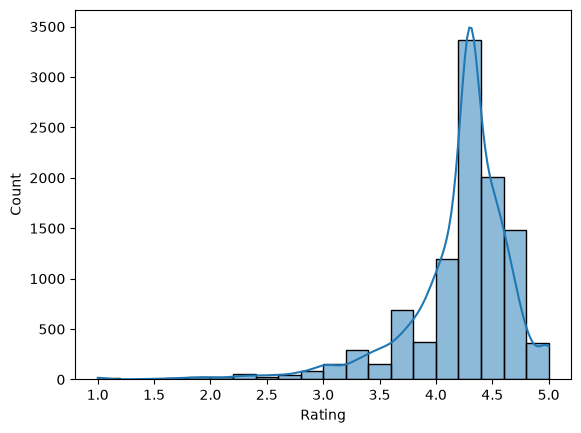

In [40]:
sns.histplot(df['Rating'], bins=20, kde=True)
plt.savefig('images/graph1.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 2. Top App Categories

*Which categories have the most apps on the Play Store*

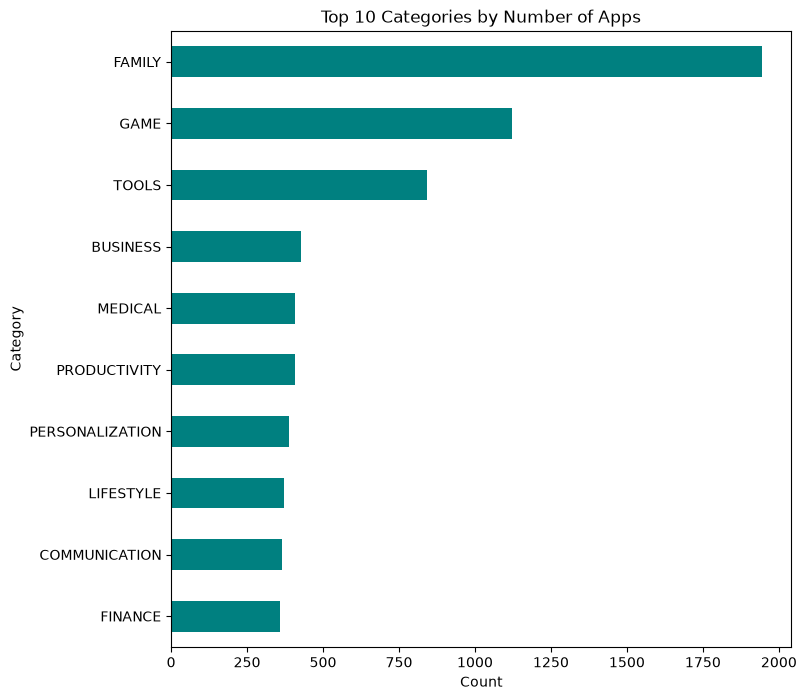

In [44]:
plt.figure(figsize=(8,8))
df['Category'].value_counts().head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Categories by Number of Apps')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.savefig('images/graph2.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 3. Free vs Paid Apps

*Comparing the count of free vs paid apps*

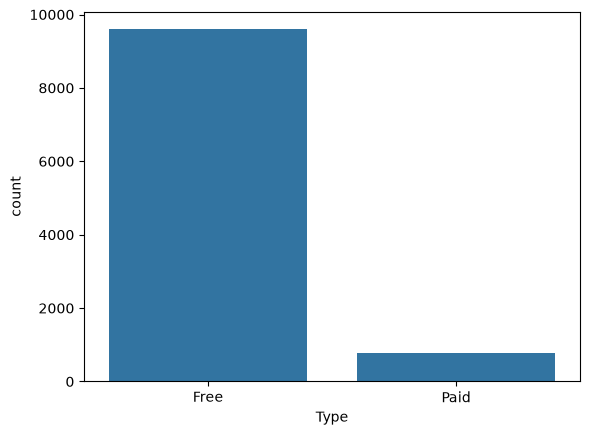

In [42]:
sns.countplot(x='Type', data=df)
plt.savefig('images/graph3.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 4. Content Rating Distribution

*Distribution of apps across content rating groups (Everyone, Teen, Mature, etc.)*

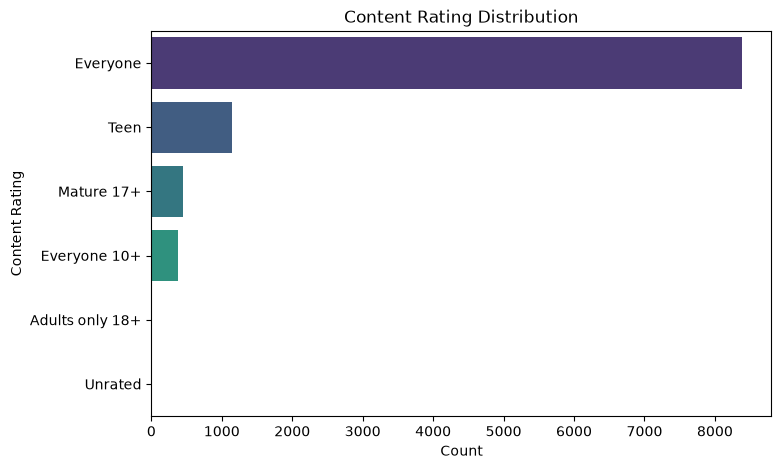

In [43]:
import warnings
warnings.filterwarnings("ignore") #this code can surpass hue and palette warnings

plt.figure(figsize=(8,5))
sns.countplot(y='Content Rating', data=df, order=df['Content Rating'].value_counts().index, palette='viridis')
plt.title('Content Rating Distribution')
plt.xlabel('Count')
plt.savefig('images/graph4.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 5. Top Categories by Total Installs

*Which categories dominate in terms of total installs*

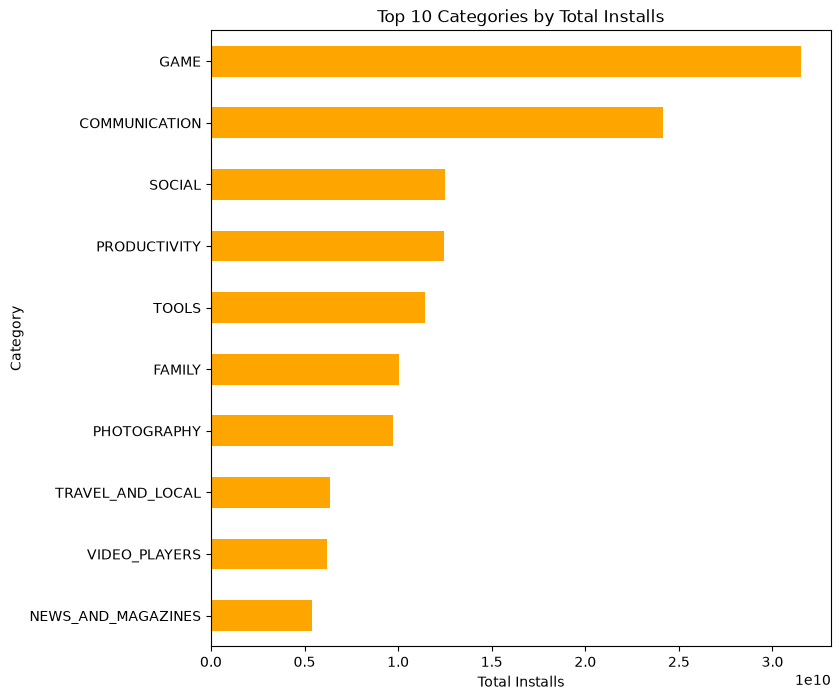

In [45]:
top_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,8))
top_installs.plot(kind='barh', color='orange')
plt.title('Top 10 Categories by Total Installs')
plt.xlabel('Total Installs')
plt.gca().invert_yaxis()
plt.savefig('images/graph5.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 6. Price Distribution of Paid Apps

*How paid apps are priced*

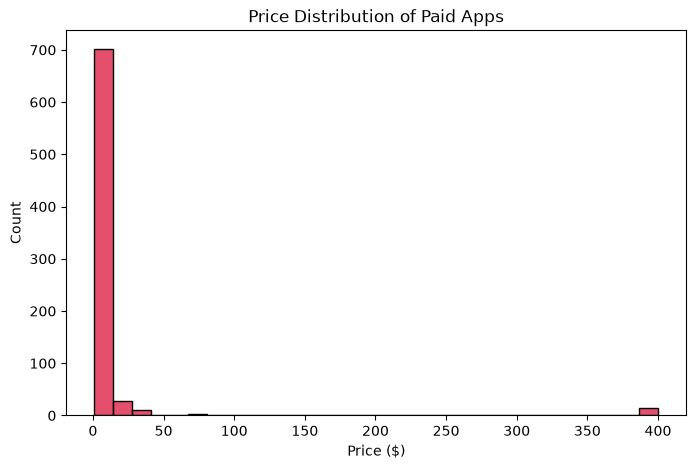

In [46]:
paid_apps = df[df['Type']=='Paid']
plt.figure(figsize=(8,5))
sns.histplot(paid_apps['Price'], bins=30, kde=False, color='crimson')
plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.savefig('images/graph6.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 7. Rating vs Reviews

*Relationship between number of reviews and rating*

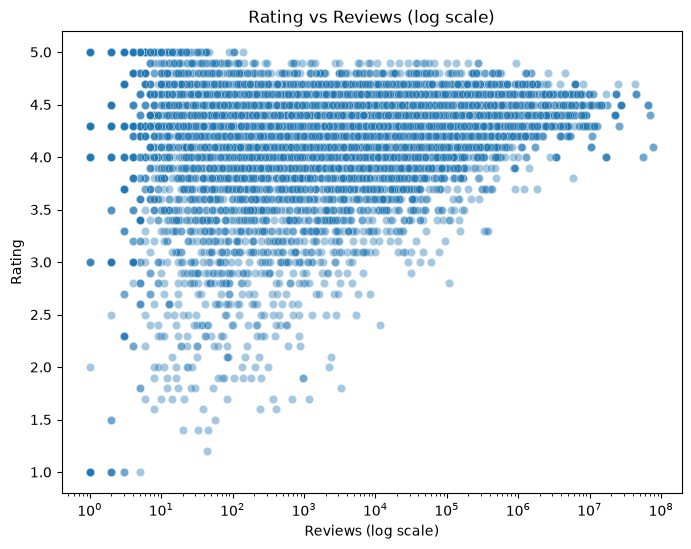

In [47]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Reviews', y='Rating', data=df, alpha=0.4)
plt.xscale('log')
plt.title('Rating vs Reviews (log scale)')
plt.xlabel('Reviews (log scale)')
plt.savefig('images/graph7.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 8. App Size vs Rating

*Does app size affect rating*

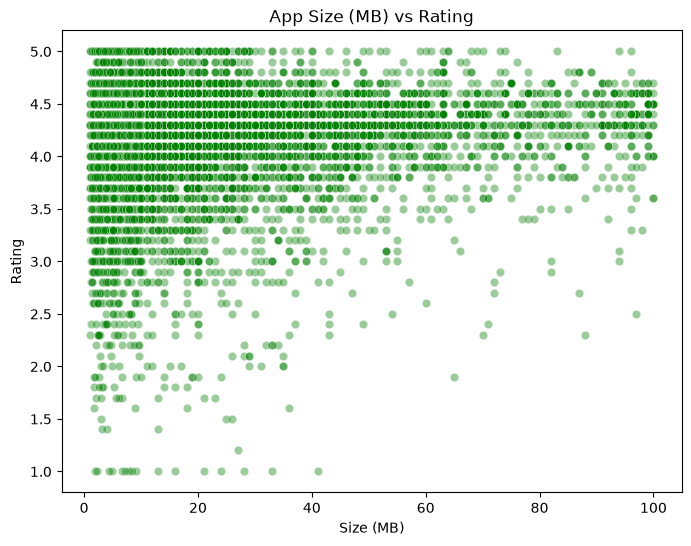

In [48]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Size', y='Rating', data=df, alpha=0.4, color='green')
plt.title('App Size (MB) vs Rating')
plt.xlabel('Size (MB)')
plt.savefig('images/graph8.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 9. Installs by Category (Boxplot)

*Spread of installs across top categories*

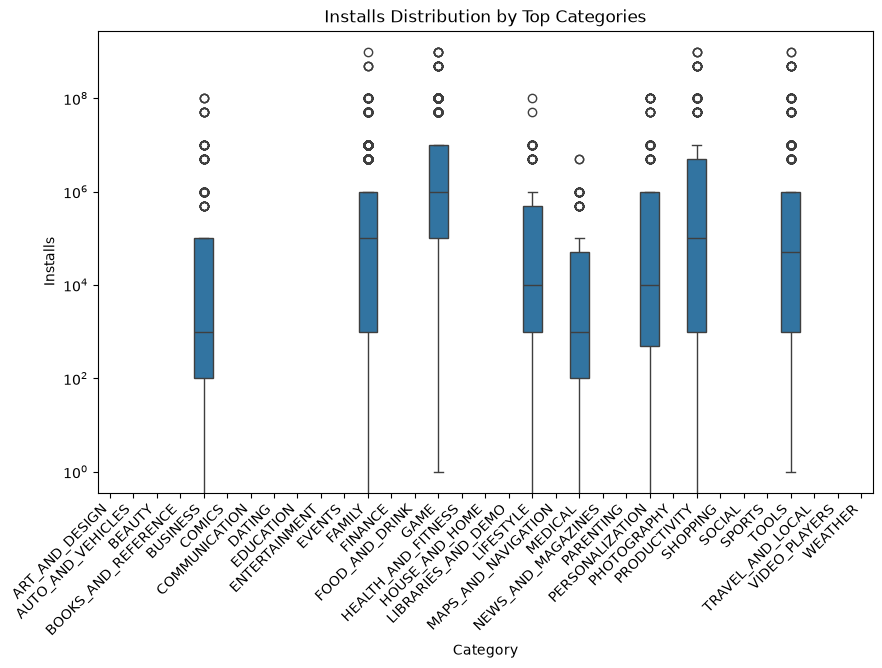

In [49]:
top_cats = df['Category'].value_counts().head(8).index
plt.figure(figsize=(10,6))
sns.boxplot(x='Category', y='Installs', data=df[df['Category'].isin(top_cats)])
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title('Installs Distribution by Top Categories')
plt.savefig('images/graph9.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 10. Correlation Heatmap

*Correlation between numeric features*

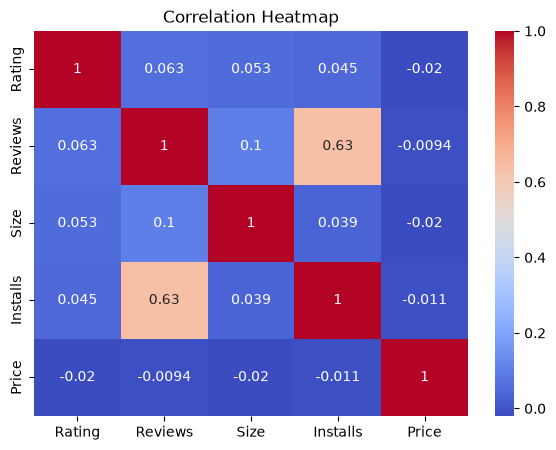

In [50]:
plt.figure(figsize=(7,5))
sns.heatmap(df[['Rating','Reviews','Size','Installs','Price']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('images/graph10.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 11. Apps Updated Over the Years

*Trend of app updates by year*

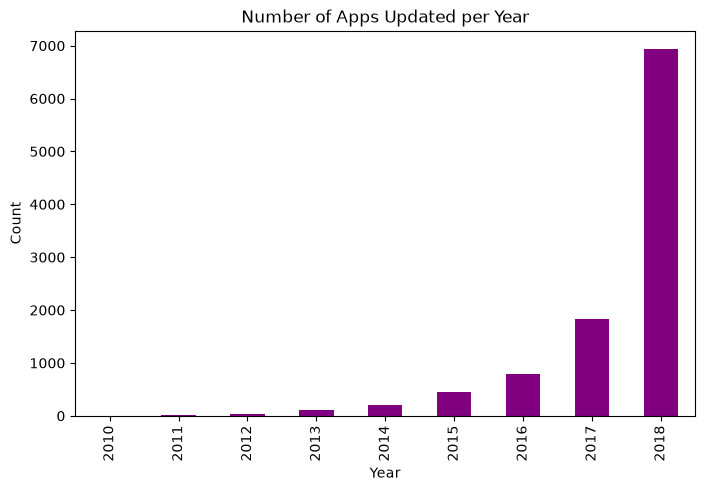

In [51]:
plt.figure(figsize=(8,5))
df['Year Updated'].value_counts().sort_index().plot(kind='bar', color='purple')
plt.title('Number of Apps Updated per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.savefig('images/graph11.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 12. Top 10 Most Expensive Paid Apps

*Highest priced apps on the store*

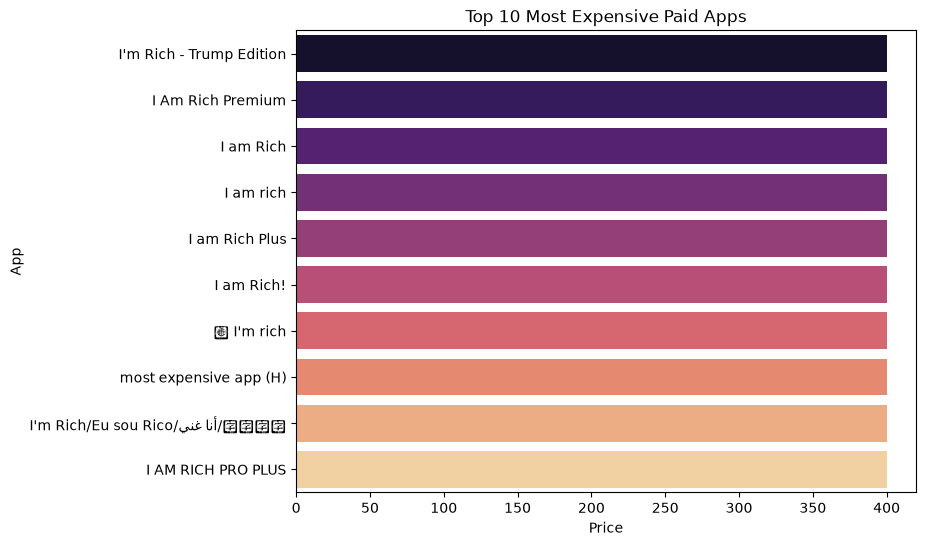

In [52]:
top_expensive = df[df['Type']=='Paid'].sort_values('Price', ascending=False).drop_duplicates('App').head(10)
plt.figure(figsize=(8,6))
sns.barplot(x='Price', y='App', data=top_expensive, palette='magma')
plt.title('Top 10 Most Expensive Paid Apps')
plt.savefig('images/graph12.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 13.Installs vs Price (Paid Apps)

*Relationship between app price and installs.*

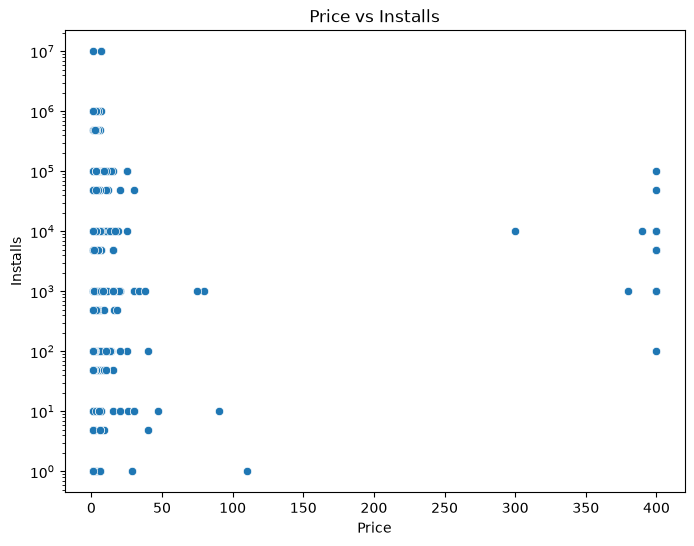

In [53]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=paid_apps, x='Price', y='Installs')
plt.yscale('log')
plt.title('Price vs Installs')
plt.savefig('images/graph13.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 14. Rating Distribution by App Type

*Rating comparison of free and paid apps.*

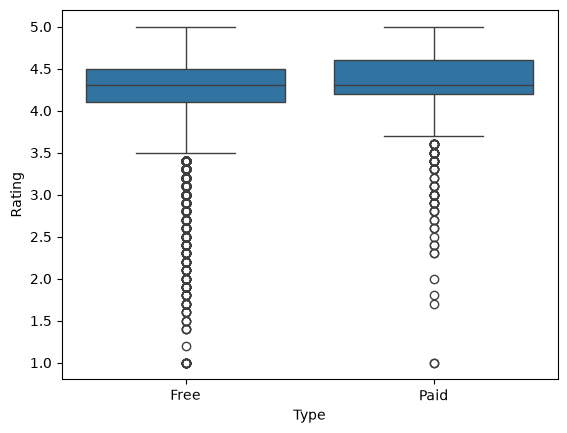

In [54]:
sns.boxplot(x='Type', y='Rating', data=df)
plt.savefig('images/graph14.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 15. Average Rating by Category

*Average rating of apps across categories.*

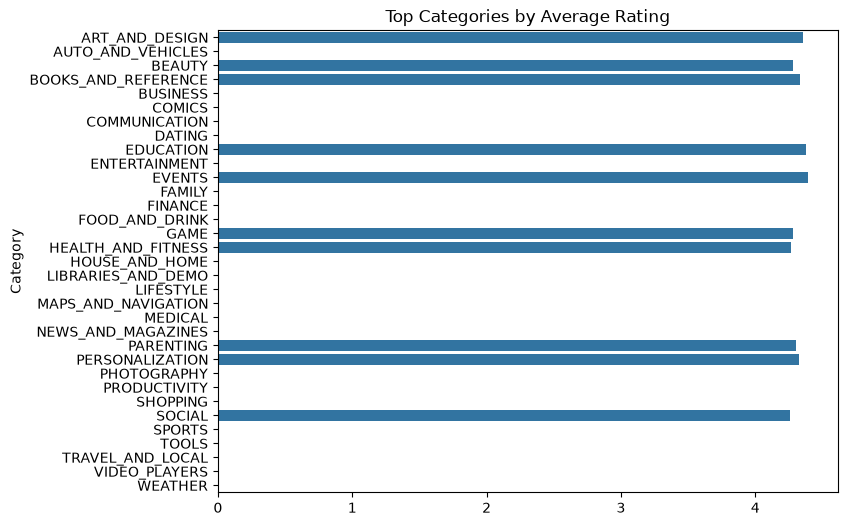

In [55]:
avg_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=avg_rating.values, y=avg_rating.index)
plt.title('Top Categories by Average Rating')
plt.savefig('images/graph15.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

## ✅ Key Takeaways
- **Rating**: Most apps are rated between 4.0 and 4.5, with an average rating of **~4.2**, showing users generally rate apps positively.
- **Category**: A handful of categories — like FAMILY, GAME, and TOOLS — account for a disproportionately large share of total apps on the store.
- **Free vs Paid**: The vast majority of apps on the Play Store are free, with paid apps making up only a small fraction of the catalog.
- **Content Rating**: Most apps are rated "Everyone," indicating the store's catalog leans heavily toward general-audience content.
- **Installs by Category**: Categories like COMMUNICATION, GAME, and TOOLS dominate in total installs, driven by a few extremely popular apps.
- **Pricing**: Paid apps are mostly priced under $5, with a long tail of a few unusually expensive niche apps.
- **Reviews vs Rating**: Apps with a very high number of reviews tend to cluster around higher ratings, though rating stays fairly stable across most review counts (log scale).
- **Size vs Rating**: App size doesn't show a strong relationship with rating — both small and large apps span the full rating range.
- **Correlation**: Numeric features like Reviews, Installs, Size, and Price show weak correlation with Rating, suggesting rating is influenced more by qualitative factors than app specs.
- **Updates**: The number of apps being actively updated rose sharply toward 2017–2018, reflecting increasing developer activity in recent years.